In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from armain import Perceptron, Adeline

In [2]:
iris = sns.load_dataset('iris')

In [3]:
iris = iris[~(iris['species'] == 'versicolor')].reset_index(drop=True)

iris_features = ['sepal_length', 'sepal_width',	'petal_length',	'petal_width']
iris_targets = ['species']

iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
95,6.7,3.0,5.2,2.3,virginica
96,6.3,2.5,5.0,1.9,virginica
97,6.5,3.0,5.2,2.0,virginica
98,6.2,3.4,5.4,2.3,virginica


In [4]:
iris[iris_features] = (iris[iris_features] - iris[iris_features].mean(axis=0)) / iris[iris_features].std(axis=0)

iris[iris_targets] = iris[iris_targets].map(lambda x: {'setosa': 0, 'virginica': 1}[x]).astype(dtype=pd.Int8Dtype())

iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,-0.737318,0.715472,-1.005622,-1.019481,0
1,-0.948886,-0.480969,-1.005622,-1.019481,0
2,-1.160455,-0.002393,-1.053350,-1.019481,0
3,-1.266240,-0.241681,-0.957894,-1.019481,0
4,-0.843102,0.954760,-1.005622,-1.019481,0
...,...,...,...,...,...
95,0.955233,-0.480969,0.808029,1.267816,1
96,0.532096,-1.677411,0.712574,0.832141,1
97,0.743665,-0.480969,0.808029,0.941060,1
98,0.426311,0.476184,0.903485,1.267816,1


In [5]:
perceptron = Perceptron(iris[iris_features], iris[iris_targets])
confusions = perceptron.fit(0.001, 5)

In [27]:
adeline = Adeline(iris[iris_features], iris[iris_targets])
train_loss, test_loss = adeline.fit(0.25, 5, 1)

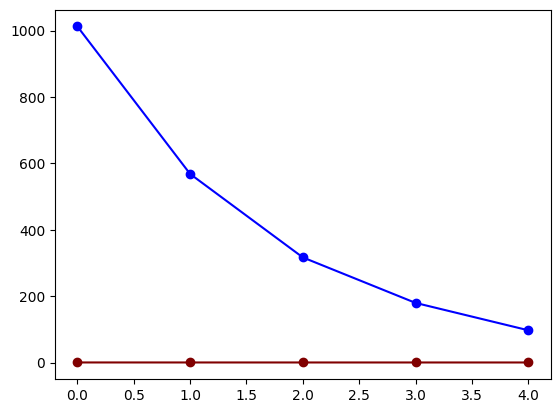

In [28]:
plt.plot(train_loss, marker='o', color='blue')
plt.plot(test_loss, marker='o', color='maroon')

plt.show()